In [1]:
import pandas as pd

# Load dataset (use correct relative path from your notebook)
df = pd.read_csv("../dataset/lung_cancer_final_realistic_10k.csv")

# Confirm loading
print("Dataset loaded successfully")

# Preview data
print(df.head())

Dataset loaded successfully
   age  gender  smoking  years_of_smoking  cigarettes_per_day  \
0   69       0        0                 0                   0   
1   64       1        0                 0                   0   
2   51       1        1                14                  33   
3   25       0        1                 5                  12   
4   32       1        0                 0                   0   

   passive_smoking  air_pollution_exposure  occupational_exposure  \
0                1                       5                      0   
1                0                       9                      0   
2                1                       8                      0   
3                0                       9                      1   
4                0                       7                      0   

   family_history  chronic_cough  chest_pain  shortness_of_breath  fatigue  \
0               0              0           0                    0        0   
1         

Data Inspection

In [2]:
# Shape of dataset
print("Dataset Shape:", df.shape)

# Column names
print("\nColumns:")
print(df.columns)

# Data types
print("\nData Types:")
print(df.dtypes)

# Missing values
print("\nMissing Values:")
print(df.isnull().sum())

# Duplicate rows
print("\nDuplicate Rows:", df.duplicated().sum())

# Target distribution (very important in medical ML)
print("\nTarget Distribution:")
print(df["target"].value_counts())

print("\nTarget Percentage:")
print(df["target"].value_counts(normalize=True) * 100)

Dataset Shape: (10000, 17)

Columns:
Index(['age', 'gender', 'smoking', 'years_of_smoking', 'cigarettes_per_day',
       'passive_smoking', 'air_pollution_exposure', 'occupational_exposure',
       'family_history', 'chronic_cough', 'chest_pain', 'shortness_of_breath',
       'fatigue', 'weight_loss', 'previous_lung_disease', 'lung_function',
       'target'],
      dtype='object')

Data Types:
age                         int64
gender                      int64
smoking                     int64
years_of_smoking            int64
cigarettes_per_day          int64
passive_smoking             int64
air_pollution_exposure      int64
occupational_exposure       int64
family_history              int64
chronic_cough               int64
chest_pain                  int64
shortness_of_breath         int64
fatigue                     int64
weight_loss                 int64
previous_lung_disease       int64
lung_function             float64
target                      int64
dtype: object

Missing V

 Data Cleaning

In [3]:
# Remove duplicate rows
df = df.drop_duplicates()

# Verify removal
print("New Shape:", df.shape)
print("Remaining Duplicates:", df.duplicated().sum())

New Shape: (9999, 17)
Remaining Duplicates: 0


 EDA (Correlation Heatmap)


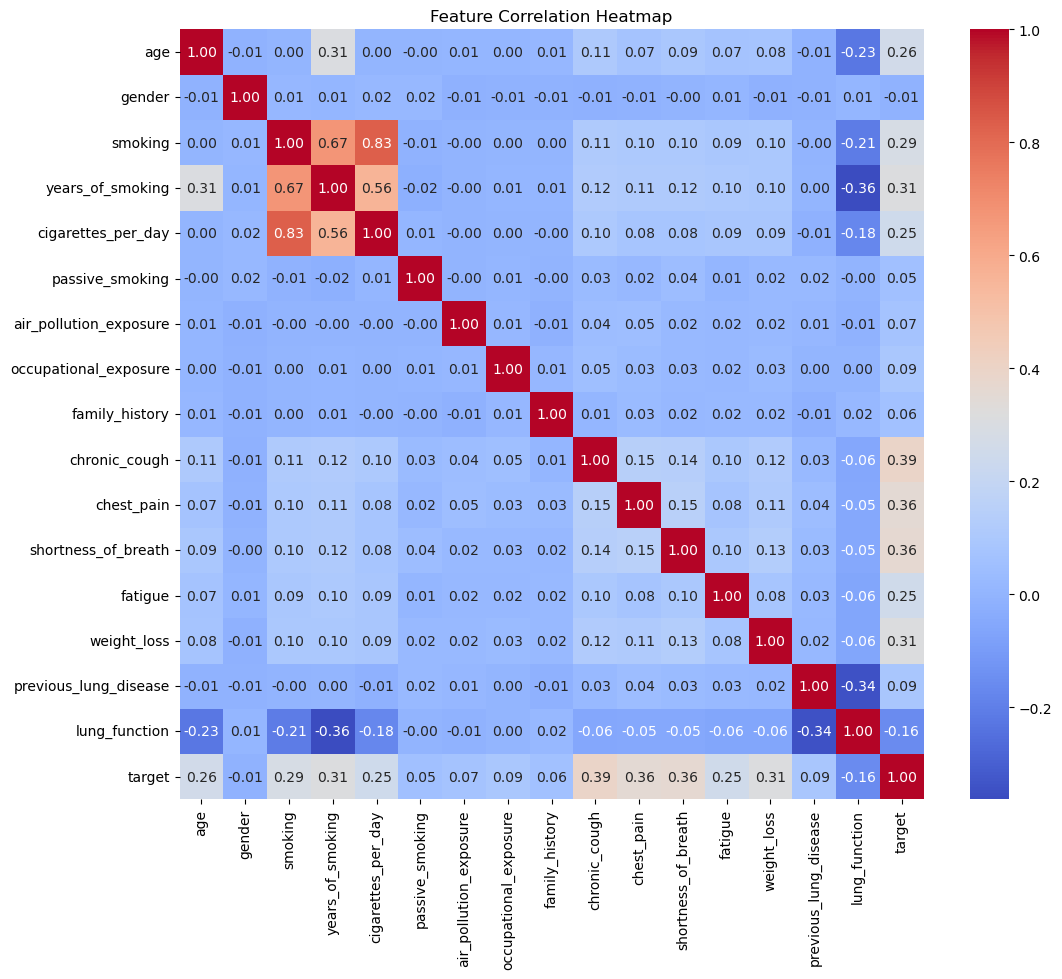

In [4]:

import matplotlib.pyplot as plt
import seaborn as sns

# Set figure size
plt.figure(figsize=(12, 10))

# Compute correlation
corr = df.corr()

# Plot heatmap
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")

plt.title("Feature Correlation Heatmap")
plt.show()


 Strong predictors of cancer (target)
	•	chronic_cough → 0.39
	•	chest_pain → 0.36
	•	shortness_of_breath → 0.36
	•	years_of_smoking → 0.31
	•	weight_loss → 0.31
	•	smoking → 0.29
	•	age → 0.26

👉 This is medically correct ✔️ (very good dataset)

⸻

⚠️ High correlation between features (MULTICOLLINEARITY)
	•	smoking ↔ cigarettes_per_day = 0.83
	•	smoking ↔ years_of_smoking = 0.67

 Feature Engineering

In [5]:
# Create better features (more powerful than raw data)

# Smoking intensity (real risk factor)
df["smoking_index"] = df["years_of_smoking"] * df["cigarettes_per_day"]

# Exposure score (environment risk)
df["exposure_score"] = (
    df["air_pollution_exposure"] +
    df["occupational_exposure"] +
    df["passive_smoking"]
)

# Health symptom score (VERY IMPORTANT for cancer detection)
df["health_score"] = (
    df["chronic_cough"] +
    df["chest_pain"] +
    df["shortness_of_breath"] +
    df["fatigue"] +
    df["weight_loss"]
)

print("Feature Engineering Done")
print(df.head())

Feature Engineering Done
   age  gender  smoking  years_of_smoking  cigarettes_per_day  \
0   69       0        0                 0                   0   
1   64       1        0                 0                   0   
2   51       1        1                14                  33   
3   25       0        1                 5                  12   
4   32       1        0                 0                   0   

   passive_smoking  air_pollution_exposure  occupational_exposure  \
0                1                       5                      0   
1                0                       9                      0   
2                1                       8                      0   
3                0                       9                      1   
4                0                       7                      0   

   family_history  chronic_cough  chest_pain  shortness_of_breath  fatigue  \
0               0              0           0                    0        0   
1            

Good question — this is one of the most important steps in real ML.

Let’s break it simply (exam + interview level) 👇

⸻

🔹 What this step is doing (Feature Engineering)

👉 You are creating new columns (features) from existing data
👉 These new features are more meaningful for the model

⸻

🧠 1. Smoking Index

df["smoking_index"] = df["years_of_smoking"] * df["cigarettes_per_day"]

✅ Meaning:
	•	Combines:
	•	how long someone smoked
	•	how much they smoked

📌 Example:
	•	10 years × 5 cigarettes = 50
	•	20 years × 20 cigarettes = 400

👉 Second person = much higher risk

🎯 Why important:

Model now understands intensity, not just yes/no smoking

⸻

🌫️ 2. Exposure Score

df["exposure_score"] = (
    df["air_pollution_exposure"] +
    df["occupational_exposure"] +
    df["passive_smoking"]
)

✅ Meaning:

Combines all environmental risks:
	•	pollution
	•	job exposure
	•	passive smoking

👉 Instead of 3 weak signals → 1 strong signal

⸻

❤️ 3. Health Score

df["health_score"] = (
    df["chronic_cough"] +
    df["chest_pain"] +
    df["shortness_of_breath"] +
    df["fatigue"] +
    df["weight_loss"]
)

✅ Meaning:

Counts symptoms

📌 Example:
	•	0 → healthy
	•	3 → moderate symptoms
	•	5 → high risk

👉 More symptoms = higher cancer probability

⸻

🔥 Why this is VERY IMPORTANT

Before:
	•	Model sees 15 separate columns
	•	Hard to learn patterns

After:
	•	Model sees clear risk indicators
	•	Easier learning → better accuracy + recall

⸻

💡 In one line (remember this for interview)

👉 Feature engineering transforms raw data into meaningful signals that improve model performance.

⸻



 Split Features and Target

In [6]:
# Separate input features (X) and target (y)

X = df.drop("target", axis=1)   # all input features
y = df["target"]                # output (0 = No Cancer, 1 = Cancer)

# Check shapes
print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (9999, 19)
Target shape: (9999,)


Train / Test Split 

In [7]:
from sklearn.model_selection import train_test_split

# Split data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,        # 80% train, 20% test
    random_state=42,      # for reproducibility
    stratify=y            # VERY IMPORTANT (keeps class balance)
)

# Check shapes
print("Training Features Shape:", X_train.shape)
print("Testing Features Shape:", X_test.shape)

print("Training Target Shape:", y_train.shape)
print("Testing Target Shape:", y_test.shape)

Training Features Shape: (7999, 19)
Testing Features Shape: (2000, 19)
Training Target Shape: (7999,)
Testing Target Shape: (2000,)


 Scaling (ONLY for Logistic Regression / SVM)


In [8]:
from sklearn.preprocessing import StandardScaler

# Create scaler
scaler = StandardScaler()

# Fit on training data and transform
X_train_scaled = scaler.fit_transform(X_train)

# Transform test data (IMPORTANT: no fit here)
X_test_scaled = scaler.transform(X_test)

# Check shapes
print("Scaled train shape:", X_train_scaled.shape)
print("Scaled test shape:", X_test_scaled.shape)

Scaled train shape: (7999, 19)
Scaled test shape: (2000, 19)


 Train Logistic Regression

In [9]:
from sklearn.linear_model import LogisticRegression

# Create model
lr = LogisticRegression(
    C=0.5,                # regularization (prevents overfitting)
    class_weight="balanced",  # important for medical problems
    max_iter=1000,
    random_state=42
)

# Train model
lr.fit(X_train_scaled, y_train)

print("Logistic Regression trained successfully")

Logistic Regression trained successfully


In [10]:
# Predict probabilities (needed for threshold tuning)
y_prob = lr.predict_proba(X_test_scaled)[:, 1]

# Use threshold = 0.4 (better for cancer detection)
threshold = 0.4
y_pred = (y_prob > threshold).astype(int)

# Evaluation
from sklearn.metrics import accuracy_score, classification_report

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy: 0.8115

Classification Report:

              precision    recall  f1-score   support

           0       0.86      0.75      0.80      1015
           1       0.77      0.87      0.82       985

    accuracy                           0.81      2000
   macro avg       0.82      0.81      0.81      2000
weighted avg       0.82      0.81      0.81      2000



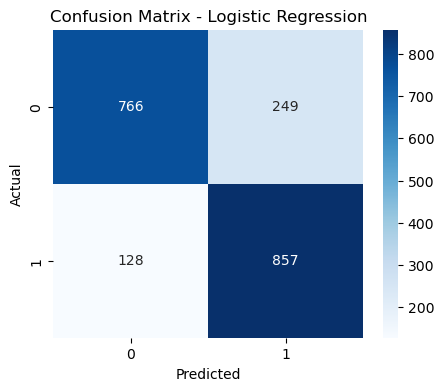

In [11]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Logistic Regression")

plt.show()

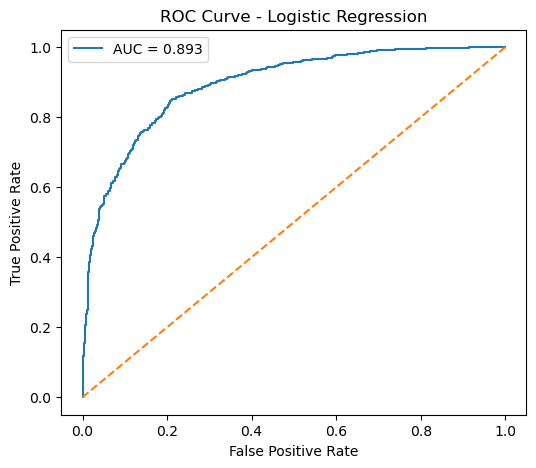

In [12]:
from sklearn.metrics import roc_curve, auc

# Compute ROC values
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

# Plot
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")

# Diagonal line (random model)
plt.plot([0,1], [0,1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend()

plt.show()

In [13]:
import pickle

# Save Logistic Regression model
with open("../models/lr_model.pkl", "wb") as f:
    pickle.dump(lr, f)

print("Logistic Regression model saved successfully")

Logistic Regression model saved successfully


In [14]:
pickle.dump(scaler, open("scaler.pkl", "wb"))

In [15]:
from sklearn.ensemble import RandomForestClassifier

# Create model (controlled to avoid overfitting)
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42
)

# Train
rf.fit(X_train, y_train)

print("Random Forest trained successfully")

Random Forest trained successfully


Evaluate Random Forest

In [16]:
from sklearn.metrics import accuracy_score, classification_report

# Predict
y_pred_rf = rf.predict(X_test)

# Evaluation
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 0.802

Classification Report:

              precision    recall  f1-score   support

           0       0.81      0.80      0.80      1015
           1       0.80      0.80      0.80       985

    accuracy                           0.80      2000
   macro avg       0.80      0.80      0.80      2000
weighted avg       0.80      0.80      0.80      2000



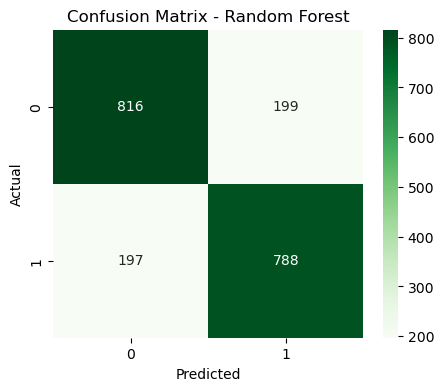

In [17]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Confusion Matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)

# Plot
plt.figure(figsize=(5,4))
sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Greens")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Random Forest")

plt.show()

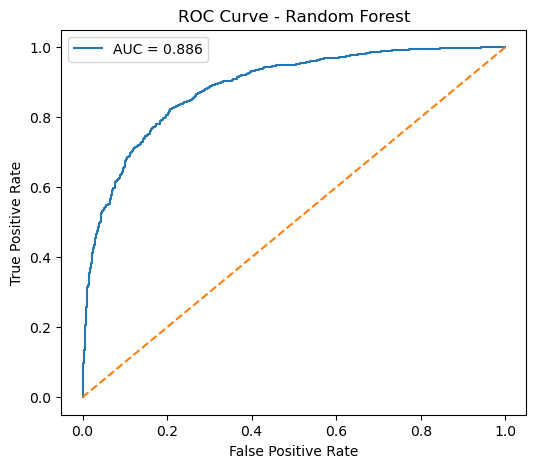

In [18]:
from sklearn.metrics import roc_curve, auc

# Get probability scores (IMPORTANT)
y_prob_rf = rf.predict_proba(X_test)[:, 1]

# Compute ROC
fpr, tpr, thresholds = roc_curve(y_test, y_prob_rf)
roc_auc = auc(fpr, tpr)

# Plot
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")

# Diagonal line
plt.plot([0,1], [0,1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Random Forest")
plt.legend()

plt.show()

In [19]:
import pickle

# Save Random Forest model
with open("../models/random_forest_model.pkl", "wb") as f:
    pickle.dump(rf, f)

print("Random Forest model saved successfully")

Random Forest model saved successfully


In [20]:
from sklearn.tree import DecisionTreeClassifier

# Create model (controlled to avoid overfitting)
dt = DecisionTreeClassifier(
    max_depth=6,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)

# Train
dt.fit(X_train, y_train)

print("Decision Tree trained successfully")

Decision Tree trained successfully


In [21]:
from sklearn.metrics import accuracy_score, classification_report

# Predict
y_pred_dt = dt.predict(X_test)

# Evaluation
print("Decision Tree Accuracy:", accuracy_score(y_test, y_pred_dt))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_dt))

Decision Tree Accuracy: 0.7905

Classification Report:

              precision    recall  f1-score   support

           0       0.79      0.79      0.79      1015
           1       0.79      0.79      0.79       985

    accuracy                           0.79      2000
   macro avg       0.79      0.79      0.79      2000
weighted avg       0.79      0.79      0.79      2000



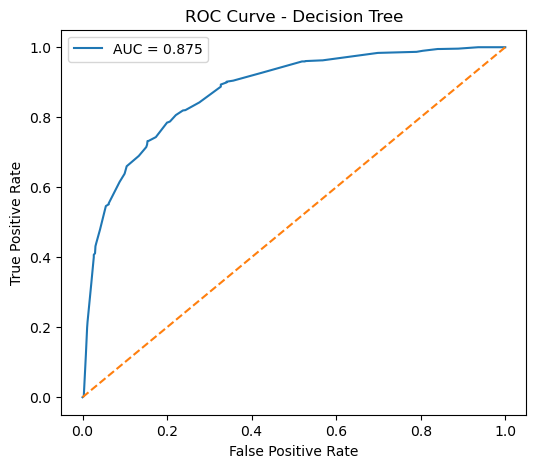

In [22]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Get probability scores
y_prob_dt = dt.predict_proba(X_test)[:, 1]

# Compute ROC
fpr, tpr, thresholds = roc_curve(y_test, y_prob_dt)
roc_auc = auc(fpr, tpr)

# Plot
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")

plt.plot([0,1], [0,1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Decision Tree")
plt.legend()

plt.show()

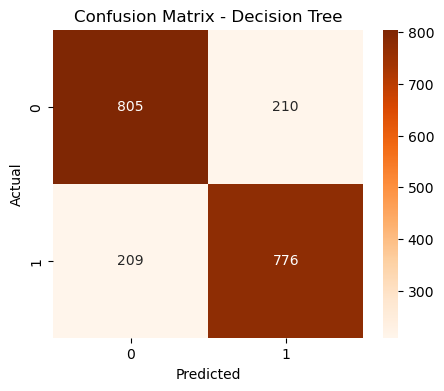

In [23]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Confusion Matrix
cm_dt = confusion_matrix(y_test, y_pred_dt)

# Plot
plt.figure(figsize=(5,4))
sns.heatmap(cm_dt, annot=True, fmt="d", cmap="Oranges")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Decision Tree")

plt.show()

In [24]:
import pickle

# Save Decision Tree model
with open("../models/decision_tree_model.pkl", "wb") as f:
    pickle.dump(dt, f)

print("Decision Tree model saved successfully")

Decision Tree model saved successfully


Train SVM

In [25]:
from sklearn.svm import SVC

# Create SVM model
svm = SVC(
    kernel="rbf",        # handles non-linear data
    C=1.0,               # regularization
    gamma="scale",       # auto adjustment
    probability=True,    # required for ROC curve
    random_state=42
)

# Train model (IMPORTANT: use scaled data)
svm.fit(X_train_scaled, y_train)

print("SVM trained successfully")

SVM trained successfully


In [26]:
from sklearn.metrics import accuracy_score, classification_report

# Predict
y_pred_svm = svm.predict(X_test_scaled)

# Evaluation
print("SVM Accuracy:", accuracy_score(y_test, y_pred_svm))

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred_svm))

SVM Accuracy: 0.803

Classification Report:

              precision    recall  f1-score   support

           0       0.80      0.82      0.81      1015
           1       0.81      0.79      0.80       985

    accuracy                           0.80      2000
   macro avg       0.80      0.80      0.80      2000
weighted avg       0.80      0.80      0.80      2000



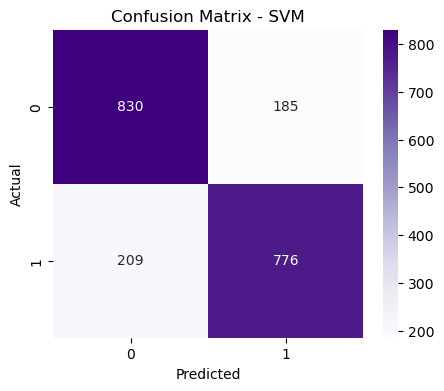

In [27]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Confusion Matrix
cm_svm = confusion_matrix(y_test, y_pred_svm)

# Plot
plt.figure(figsize=(5,4))
sns.heatmap(cm_svm, annot=True, fmt="d", cmap="Purples")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - SVM")

plt.show()

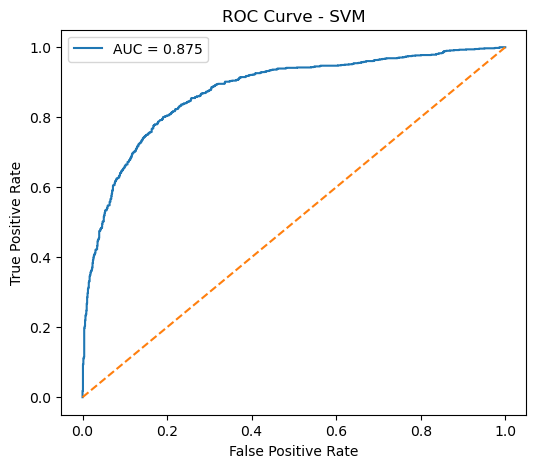

In [28]:
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

# Get probabilities
y_prob_svm = svm.predict_proba(X_test_scaled)[:, 1]

# Compute ROC
fpr, tpr, thresholds = roc_curve(y_test, y_prob_svm)
roc_auc = auc(fpr, tpr)

# Plot
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")

plt.plot([0,1], [0,1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - SVM")
plt.legend()

plt.show()

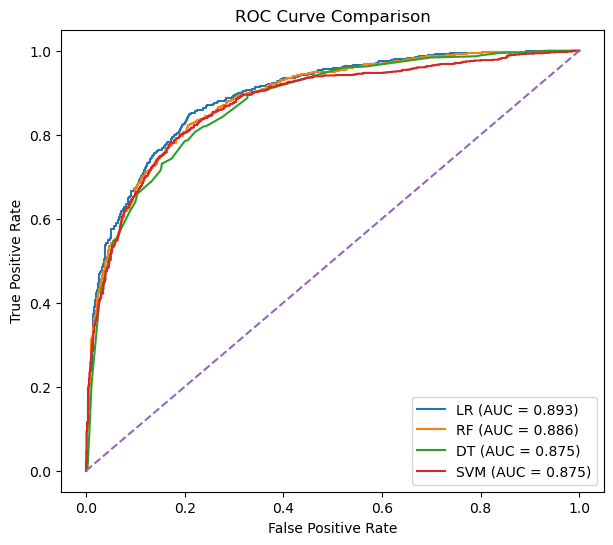

In [29]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(7,6))

# Logistic Regression
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob)
auc_lr = auc(fpr_lr, tpr_lr)
plt.plot(fpr_lr, tpr_lr, label=f"LR (AUC = {auc_lr:.3f})")

# Random Forest
y_prob_rf = rf.predict_proba(X_test)[:,1]
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
auc_rf = auc(fpr_rf, tpr_rf)
plt.plot(fpr_rf, tpr_rf, label=f"RF (AUC = {auc_rf:.3f})")

# Decision Tree
y_prob_dt = dt.predict_proba(X_test)[:,1]
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_prob_dt)
auc_dt = auc(fpr_dt, tpr_dt)
plt.plot(fpr_dt, tpr_dt, label=f"DT (AUC = {auc_dt:.3f})")

# SVM
y_prob_svm = svm.predict_proba(X_test_scaled)[:,1]
fpr_svm, tpr_svm, _ = roc_curve(y_test, y_prob_svm)
auc_svm = auc(fpr_svm, tpr_svm)
plt.plot(fpr_svm, tpr_svm, label=f"SVM (AUC = {auc_svm:.3f})")

# Random line
plt.plot([0,1], [0,1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend()

plt.show()

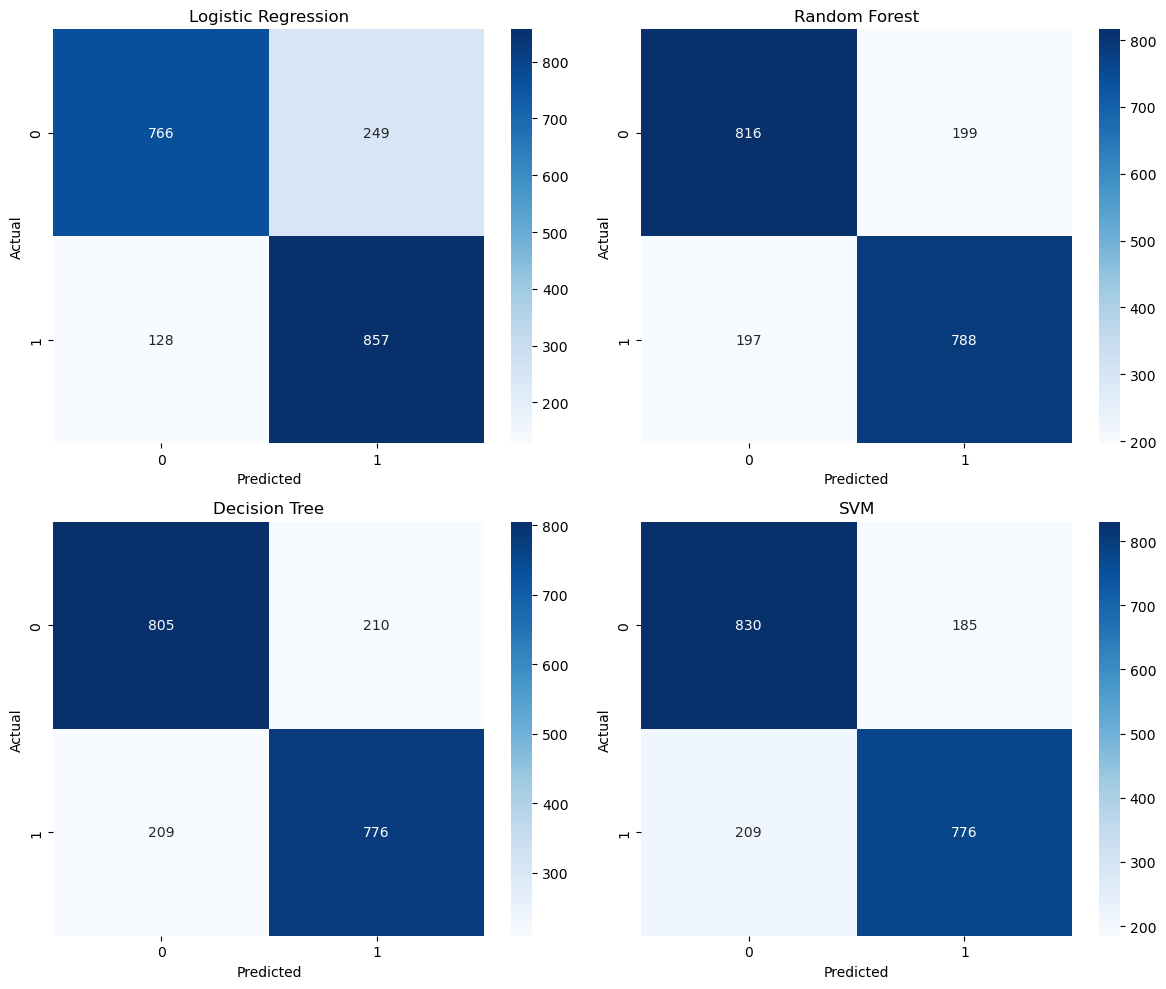

In [30]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

models = {
    "Logistic Regression": y_pred,
    "Random Forest": y_pred_rf,
    "Decision Tree": y_pred_dt,
    "SVM": y_pred_svm
}

plt.figure(figsize=(12,10))

for i, (name, pred) in enumerate(models.items(), 1):
    plt.subplot(2,2,i)
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.title(name)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")

plt.tight_layout()
plt.show()

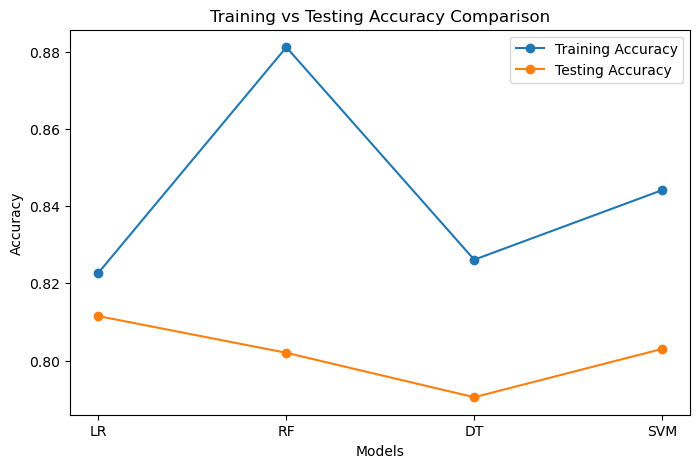

In [31]:
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score

# Calculate training accuracy
train_acc_lr = accuracy_score(y_train, lr.predict(X_train_scaled))
test_acc_lr = accuracy_score(y_test, y_pred)

train_acc_rf = accuracy_score(y_train, rf.predict(X_train))
test_acc_rf = accuracy_score(y_test, y_pred_rf)

train_acc_dt = accuracy_score(y_train, dt.predict(X_train))
test_acc_dt = accuracy_score(y_test, y_pred_dt)

train_acc_svm = accuracy_score(y_train, svm.predict(X_train_scaled))
test_acc_svm = accuracy_score(y_test, y_pred_svm)

# Store values
models = ["LR", "RF", "DT", "SVM"]
train_scores = [train_acc_lr, train_acc_rf, train_acc_dt, train_acc_svm]
test_scores = [test_acc_lr, test_acc_rf, test_acc_dt, test_acc_svm]

# Plot
x = range(len(models))

plt.figure(figsize=(8,5))

plt.plot(x, train_scores, marker='o', label="Training Accuracy")
plt.plot(x, test_scores, marker='o', label="Testing Accuracy")

plt.xticks(x, models)
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.title("Training vs Testing Accuracy Comparison")
plt.legend()

plt.show()

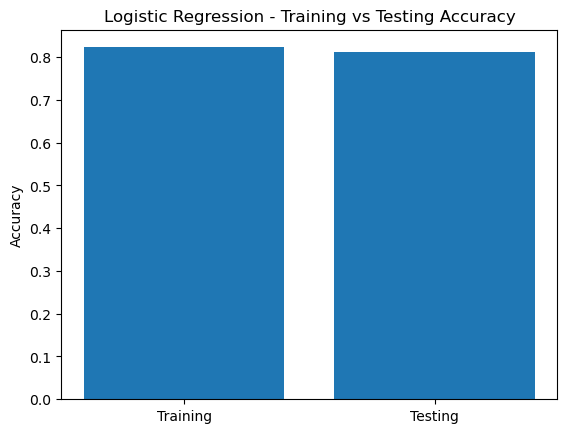

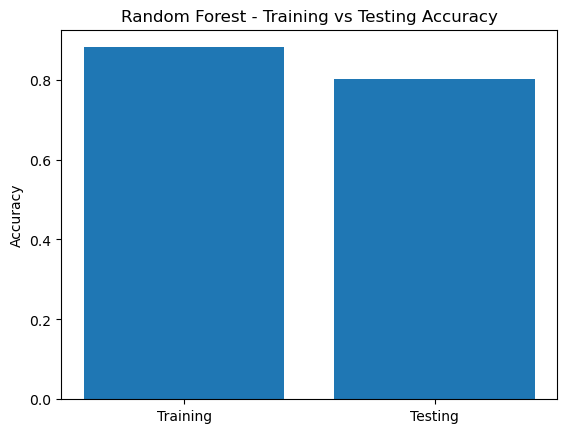

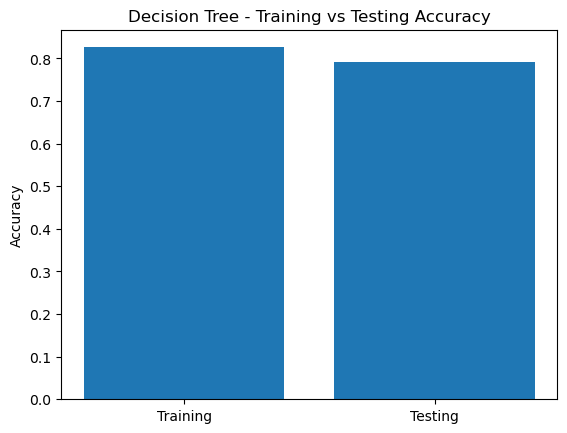

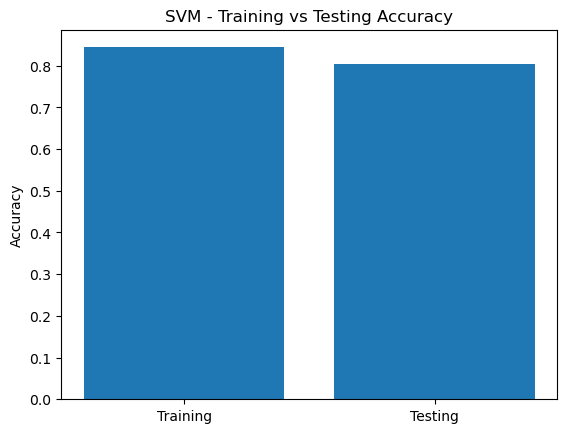

In [32]:
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score

# Calculate accuracies
train_acc_lr = accuracy_score(y_train, lr.predict(X_train_scaled))
test_acc_lr = accuracy_score(y_test, y_pred)

train_acc_rf = accuracy_score(y_train, rf.predict(X_train))
test_acc_rf = accuracy_score(y_test, y_pred_rf)

train_acc_dt = accuracy_score(y_train, dt.predict(X_train))
test_acc_dt = accuracy_score(y_test, y_pred_dt)

train_acc_svm = accuracy_score(y_train, svm.predict(X_train_scaled))
test_acc_svm = accuracy_score(y_test, y_pred_svm)

# Store in dictionary
results = {
    "Logistic Regression": (train_acc_lr, test_acc_lr),
    "Random Forest": (train_acc_rf, test_acc_rf),
    "Decision Tree": (train_acc_dt, test_acc_dt),
    "SVM": (train_acc_svm, test_acc_svm)
}

# Plot individual graphs
for model, (train_acc, test_acc) in results.items():
    plt.figure()
    
    plt.bar(["Training", "Testing"], [train_acc, test_acc])
    
    plt.title(f"{model} - Training vs Testing Accuracy")
    plt.ylabel("Accuracy")
    
    plt.show()

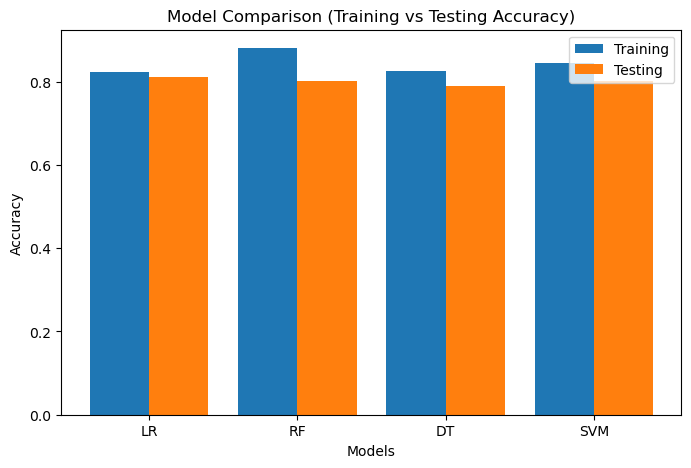

In [33]:
import matplotlib.pyplot as plt

models = ["LR", "RF", "DT", "SVM"]

train_scores = [train_acc_lr, train_acc_rf, train_acc_dt, train_acc_svm]
test_scores = [test_acc_lr, test_acc_rf, test_acc_dt, test_acc_svm]

x = range(len(models))

plt.figure(figsize=(8,5))

# Training bars
plt.bar([i - 0.2 for i in x], train_scores, width=0.4, label="Training")

# Testing bars
plt.bar([i + 0.2 for i in x], test_scores, width=0.4, label="Testing")

plt.xticks(x, models)
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.title("Model Comparison (Training vs Testing Accuracy)")
plt.legend()

plt.show()

In [34]:
import pickle

# 1. Feature names nikalna (Tumhare 'X' variable se)
feature_cols = list(X.columns)

# 2. Deployment Package Dictionary banana
lung_cancer_deployment_package = {
    'model': lr,                # Tumhara trained Logistic Regression model
    'scaler': scaler,           # Is baar scaler dena BOHOT zaroori hai!
    'feature_names': feature_cols, # Column names aur unka order
    'optimal_threshold': 0.4    # Tumhara tuned threshold!
}

# 3. Disk par save karna
with open("lung_cancer_lr_model.pkl", "wb") as f:
    pickle.dump(lung_cancer_deployment_package, f)

print("✅ Lung Cancer LR Model, Scaler, aur Metadata successfully save ho gaye hain: 'lung_cancer_lr_model.pkl'")


✅ Lung Cancer LR Model, Scaler, aur Metadata successfully save ho gaye hain: 'lung_cancer_lr_model.pkl'


In [35]:
import pickle
import pandas as pd

# Load the saved model package
with open("lung_cancer_lr_model.pkl", "rb") as f:
    loaded_package = pickle.load(f)

test_model = loaded_package['model']
test_features = loaded_package['feature_names']
test_scaler = loaded_package['scaler']
test_threshold = loaded_package['optimal_threshold']

print("✅ Model File Loaded Successfully!\n")
print(f"👉 Model Type: {type(test_model)}")
print(f"👉 Scaler Present: {test_scaler is not None}")
print(f"👉 Threshold: {test_threshold}")
print(f"👉 Total Features Expected: {len(test_features)}\n")

# Dummy Patient Data for Testing
dummy_data = {col: [0.0] for col in test_features}
dummy_df = pd.DataFrame(dummy_data)

print("--- 🏥 Running Mock Prediction ---")

# CRITICAL STEP: Scale the dummy data before passing to Logistic Regression
dummy_scaled = test_scaler.transform(dummy_df)

# Predict Probabilities
probability = test_model.predict_proba(dummy_scaled)[0][1]

# Use custom threshold (0.4) instead of default (0.5)
if probability >= test_threshold:
    print(f"Result: 🚨 High Risk of Lung Cancer (Probability: {probability*100:.2f}%)")
else:
    print(f"Result: ✅ Low Risk of Lung Cancer (Probability: {probability*100:.2f}%)")
    
print("\n🎉 Tabular ML Pipeline is now 100% COMPLETE!")


✅ Model File Loaded Successfully!

👉 Model Type: <class 'sklearn.linear_model._logistic.LogisticRegression'>
👉 Scaler Present: True
👉 Threshold: 0.4
👉 Total Features Expected: 19

--- 🏥 Running Mock Prediction ---
Result: ✅ Low Risk of Lung Cancer (Probability: 0.24%)

🎉 Tabular ML Pipeline is now 100% COMPLETE!
